# Proyecto 3 - Clustering de clientes con K-Means

## Integrantes
- Daniel Fernando Salgado Santamaría
- Jairo Wladimir Jhayya Perlaza
- Luis Gabriel Salgado Santamaría
- Oscar Paul Naranjo Castro

**Fecha:** 2026-05-13  
**Notebook:** 03-jj-clustering-clientes.ipynb

## Objetivo
Aplicar clustering no supervisado sobre la tabla `customer_features.csv` para identificar segmentos de clientes con comportamientos similares.

Se evaluará el número adecuado de clusters mediante:
- método del codo,
- silhouette score,
- análisis descriptivo de los segmentos generados.

In [1]:
# Importa librerías necesarias para rutas, análisis, visualización y clustering.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Configura opciones de visualización de pandas.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# Configura estilo visual global del notebook.
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 400
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

In [4]:
# Define una paleta viva pero profesional para mantener uniformidad visual.
PALETTE_VIVID = [
    "#0F766E",
    "#2563EB",
    "#DC2626",
    "#F59E0B",
    "#7C3AED",
    "#059669",
    "#EA580C",
    "#DB2777",
    "#0891B2",
    "#65A30D",
]

In [5]:
# Define rutas del proyecto y carpetas de salida.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

CLUSTER_FIG_DIR = FIGURES_DIR / "clustering_clientes"
CLUSTER_FIG_DIR.mkdir(parents=True, exist_ok=True)

for path in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("CLUSTER_FIG_DIR:", CLUSTER_FIG_DIR)

PROJECT_ROOT: G:\ProyectosPython\proyecto3\desarrollo3
PROCESSED_DIR: G:\ProyectosPython\proyecto3\desarrollo3\data\processed
CLUSTER_FIG_DIR: G:\ProyectosPython\proyecto3\desarrollo3\reports\figures\clustering_clientes


In [6]:
# Define función para guardar figuras en alta resolución.
def save_plot(filename):
    plt.savefig(CLUSTER_FIG_DIR / filename, dpi=400, bbox_inches="tight", facecolor="white")

In [7]:
# Define función auxiliar para etiquetar barras verticales con valores o porcentajes.
def annotate_bars(ax, fmt="{:.2f}", suffix="", fontsize=10, weight="bold"):
    for patch in ax.patches:
        height = patch.get_height()
        if pd.notnull(height):
            x = patch.get_x() + patch.get_width() / 2
            ax.annotate(
                fmt.format(height) + suffix,
                (x, height),
                ha="center",
                va="bottom",
                fontsize=fontsize,
                fontweight=weight,
                xytext=(0, 6),
                textcoords="offset points"
            )

## Carga de datos

Se carga la tabla consolidada de clientes generada en el notebook anterior.

In [8]:
# Carga la tabla de características consolidadas de clientes.
customer_features = pd.read_csv(PROCESSED_DIR / "customer_features.csv")

print(customer_features.shape)
customer_features.head()

(20000, 10)


,customer_id,country,age,signup_date,marketing_opt_in,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,1,JP,71,2020-09-04,True,5.00,2.00,115.39,57.69,1.00
1,2,IN,26,2020-04-05,False,3.00,2.00,68.52,34.26,0.00
2,3,BR,21,2023-08-31,True,5.00,1.00,66.72,66.72,0.00
3,4,FR,63,2022-06-30,True,9.00,2.00,279.86,139.93,0.00
4,5,BR,19,2022-07-22,True,9.00,3.00,271.29,90.43,4.00


In [9]:
# Muestra la estructura general de las variables disponibles.
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          20000 non-null  int64  
 1   country              20000 non-null  str    
 2   age                  20000 non-null  int64  
 3   signup_date          20000 non-null  str    
 4   marketing_opt_in     20000 non-null  bool   
 5   n_sessions           20000 non-null  float64
 6   n_orders             20000 non-null  float64
 7   gross_revenue_usd    20000 non-null  float64
 8   avg_order_value_usd  20000 non-null  float64
 9   n_reviews            20000 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(2)
memory usage: 1.4 MB


## Selección de variables para clustering

Se seleccionan variables numéricas asociadas al comportamiento del cliente para evitar mezclar directamente variables categóricas en K-Means.

In [10]:
# Define las variables numéricas que se usarán en el clustering.
cluster_features = [
    "age",
    "n_sessions",
    "n_orders",
    "gross_revenue_usd",
    "avg_order_value_usd",
    "n_reviews"
]

X = customer_features[cluster_features].copy()

print(X.head())

   age  n_sessions  n_orders  gross_revenue_usd  avg_order_value_usd  n_reviews
0   71        5.00      2.00             115.39                57.69       1.00
1   26        3.00      2.00              68.52                34.26       0.00
2   21        5.00      1.00              66.72                66.72       0.00
3   63        9.00      2.00             279.86               139.93       0.00
4   19        9.00      3.00             271.29                90.43       4.00


In [11]:
# Revisa nulos antes del escalado.
print(X.isnull().sum())

age                    0
n_sessions             0
n_orders               0
gross_revenue_usd      0
avg_order_value_usd    0
n_reviews              0
dtype: int64


In [12]:
# Escala las variables para que todas contribuyan de forma comparable al algoritmo K-Means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape escalado:", X_scaled.shape)

Shape escalado: (20000, 6)


## Evaluación del número de clusters

Se prueba una secuencia de valores de k para analizar:
- inercia (método del codo),
- silhouette score.

In [13]:
# Evalúa varios valores de k con K-Means usando inercia y silhouette score.
k_values = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

evaluation_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

evaluation_df

,k,inertia,silhouette_score
0,2,"86,894.49",0.30
1,3,"76,032.62",0.26
2,4,"66,362.27",0.23
3,5,"57,772.15",0.22
4,6,"53,163.20",0.20
5,7,"49,236.69",0.19
6,8,"46,345.51",0.20
7,9,"43,706.24",0.20
8,10,"41,677.03",0.20


La tabla anterior confirma que el mayor silhouette score se obtiene con \(k=2\) (≈ 0.30), mientras que para \(k \geq 3\) la calidad de separación entre clusters disminuye de forma consistente. Por ello, se adopta \(k=2\) como número óptimo de segmentos para el análisis de esta sección.

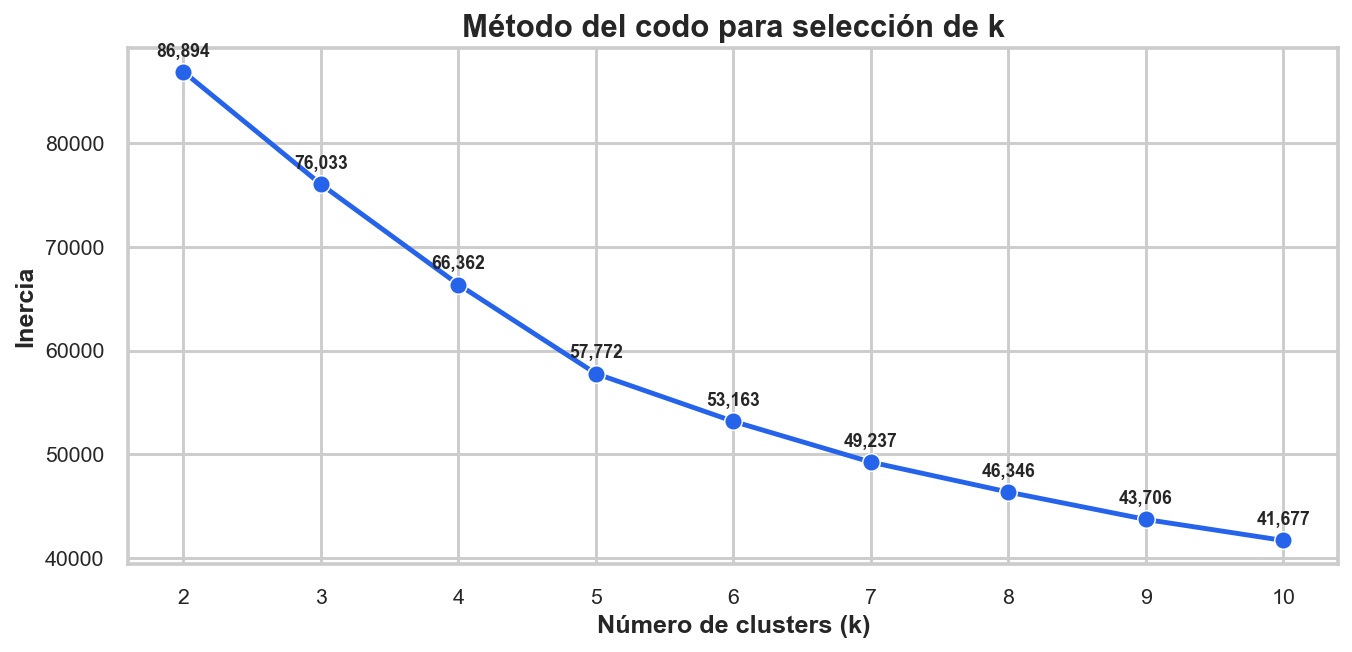

In [14]:
# Grafica la curva del codo e incluye la inercia exacta sobre cada punto.
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=evaluation_df,
    x="k",
    y="inertia",
    marker="o",
    linewidth=2.5,
    color=PALETTE_VIVID[1]
)

for x_val, y_val in zip(evaluation_df["k"], evaluation_df["inertia"]):
    ax.annotate(
        f"{y_val:,.0f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Método del codo para selección de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.tight_layout()
save_plot("metodo_codo_kmeans.png")
plt.show()

El método del codo muestra que la reducción de inercia es más pronunciada al pasar de \(k=2\) a \(k=3\), y se desacelera progresivamente para valores superiores. Esto indica que \(k=2\) representa el punto de mayor ganancia de compacidad relativa antes de que la mejora incremental se vuelva marginal.

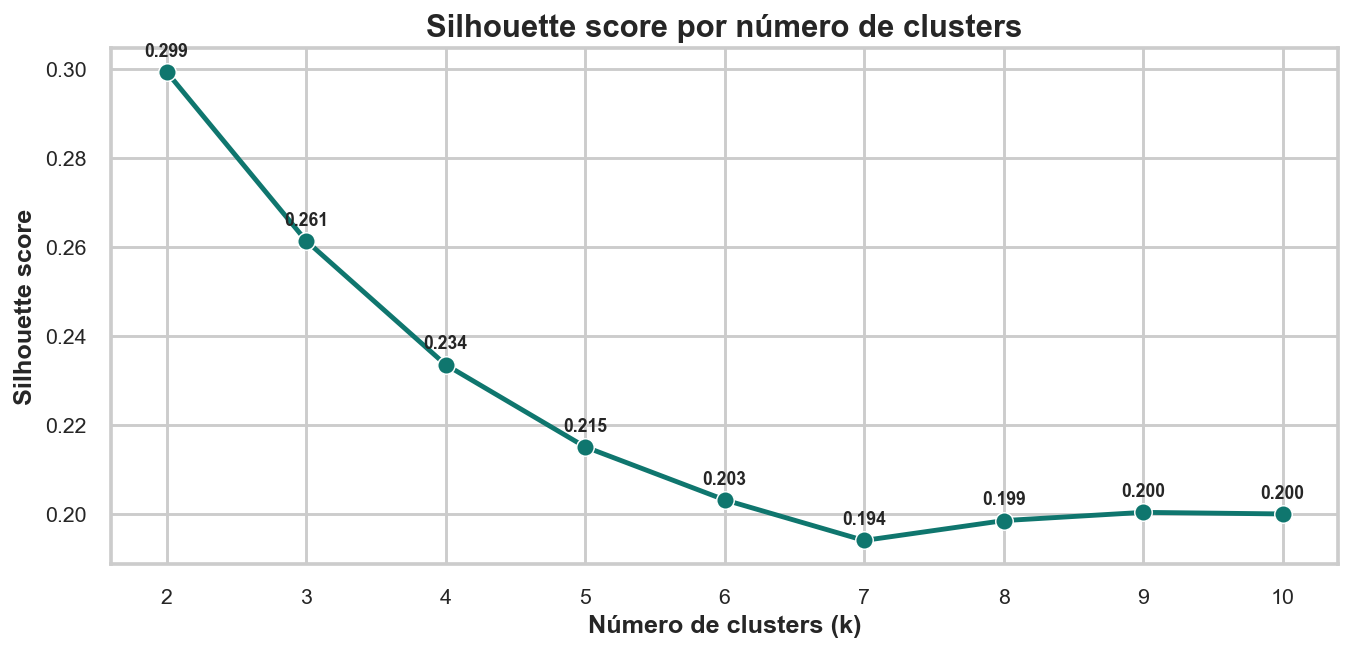

In [15]:
# Grafica el silhouette score e incluye el valor exacto sobre cada punto.
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=evaluation_df,
    x="k",
    y="silhouette_score",
    marker="o",
    linewidth=2.5,
    color=PALETTE_VIVID[0]
)

for x_val, y_val in zip(evaluation_df["k"], evaluation_df["silhouette_score"]):
    ax.annotate(
        f"{y_val:.3f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Silhouette score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
save_plot("silhouette_score_kmeans.png")
plt.show()

## Selección del modelo final

Con base en los resultados del codo y silhouette, se elige un valor final de k para construir la segmentación.

In [16]:
# Selecciona el mejor k según el máximo silhouette score.
best_k = evaluation_df.loc[evaluation_df["silhouette_score"].idxmax(), "k"]
best_k = int(best_k)

print(f"Mejor número de clusters según silhouette score: {best_k}")

Mejor número de clusters según silhouette score: 2


In [17]:
# Entrena el modelo final K-Means con el número de clusters seleccionado.
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
customer_features["cluster"] = kmeans_final.fit_predict(X_scaled)

customer_features[["customer_id", "cluster"]].head()

,customer_id,cluster
0,1,1
1,2,1
2,3,1
3,4,0
4,5,0


In [18]:
# Calcula el tamaño de cada cluster y su porcentaje respecto al total de clientes.
cluster_sizes = (
    customer_features["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="customers_count")
)

cluster_sizes["percentage"] = (
    cluster_sizes["customers_count"] / cluster_sizes["customers_count"].sum() * 100
).round(2)

cluster_sizes

,cluster,customers_count,percentage
0,0,7041,35.20
1,1,12959,64.80


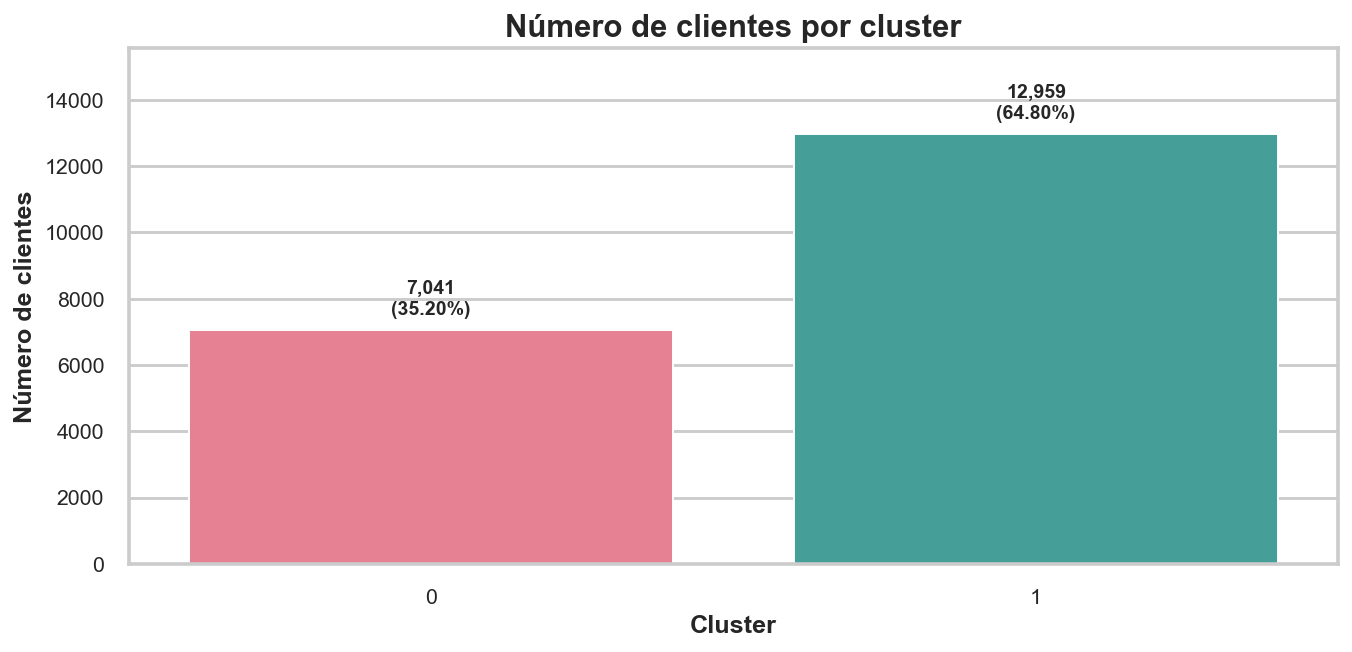

In [19]:
# Grafica el número de clientes por cluster e incluye cantidad y porcentaje en cada barra.
plt.figure(figsize=(10, 5))

palette_clusters = sns.color_palette("husl", n_colors=len(cluster_sizes))

ax = sns.barplot(
    data=cluster_sizes,
    x="cluster",
    y="customers_count",
    hue="cluster",
    dodge=False,
    legend=False,
    palette=palette_clusters,
    edgecolor="white",
    linewidth=1
)

for i, patch in enumerate(ax.patches):
    height = patch.get_height()
    pct = cluster_sizes.loc[i, "percentage"]
    ax.annotate(
        f"{height:,.0f}\n({pct:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points"
    )

plt.title("Número de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.ylim(0, cluster_sizes["customers_count"].max() * 1.20)
plt.tight_layout()
save_plot("tamano_clusters.png")
plt.show()

## Perfilamiento de clusters

Se calcula el promedio de las variables numéricas en cada cluster para interpretar el comportamiento característico de cada segmento.

In [20]:
# Calcula el perfil promedio de cada cluster en variables numéricas clave.
cluster_profile = (
    customer_features
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
    .reset_index()
)

cluster_profile

,cluster,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,0,46.97,7.65,2.86,476.67,193.40,1.21
1,1,46.23,5.10,1.04,87.74,63.35,0.18


In [21]:
# Guarda la tabla descriptiva de clusters para análisis posterior.
cluster_profile_output = TABLES_DIR / "cluster_profile_kmeans.csv"
cluster_profile.to_csv(cluster_profile_output, index=False)

print(f"Tabla guardada en: {cluster_profile_output}")

Tabla guardada en: G:\ProyectosPython\proyecto3\desarrollo3\reports\tables\cluster_profile_kmeans.csv


In [22]:
# Convierte la tabla de perfil a formato largo para construir un gráfico comparativo.
cluster_profile_long = cluster_profile.melt(
    id_vars="cluster",
    var_name="metric",
    value_name="mean_value"
)

cluster_profile_long.head()

,cluster,metric,mean_value
0,0,age,46.97
1,1,age,46.23
2,0,n_sessions,7.65
3,1,n_sessions,5.10
4,0,n_orders,2.86


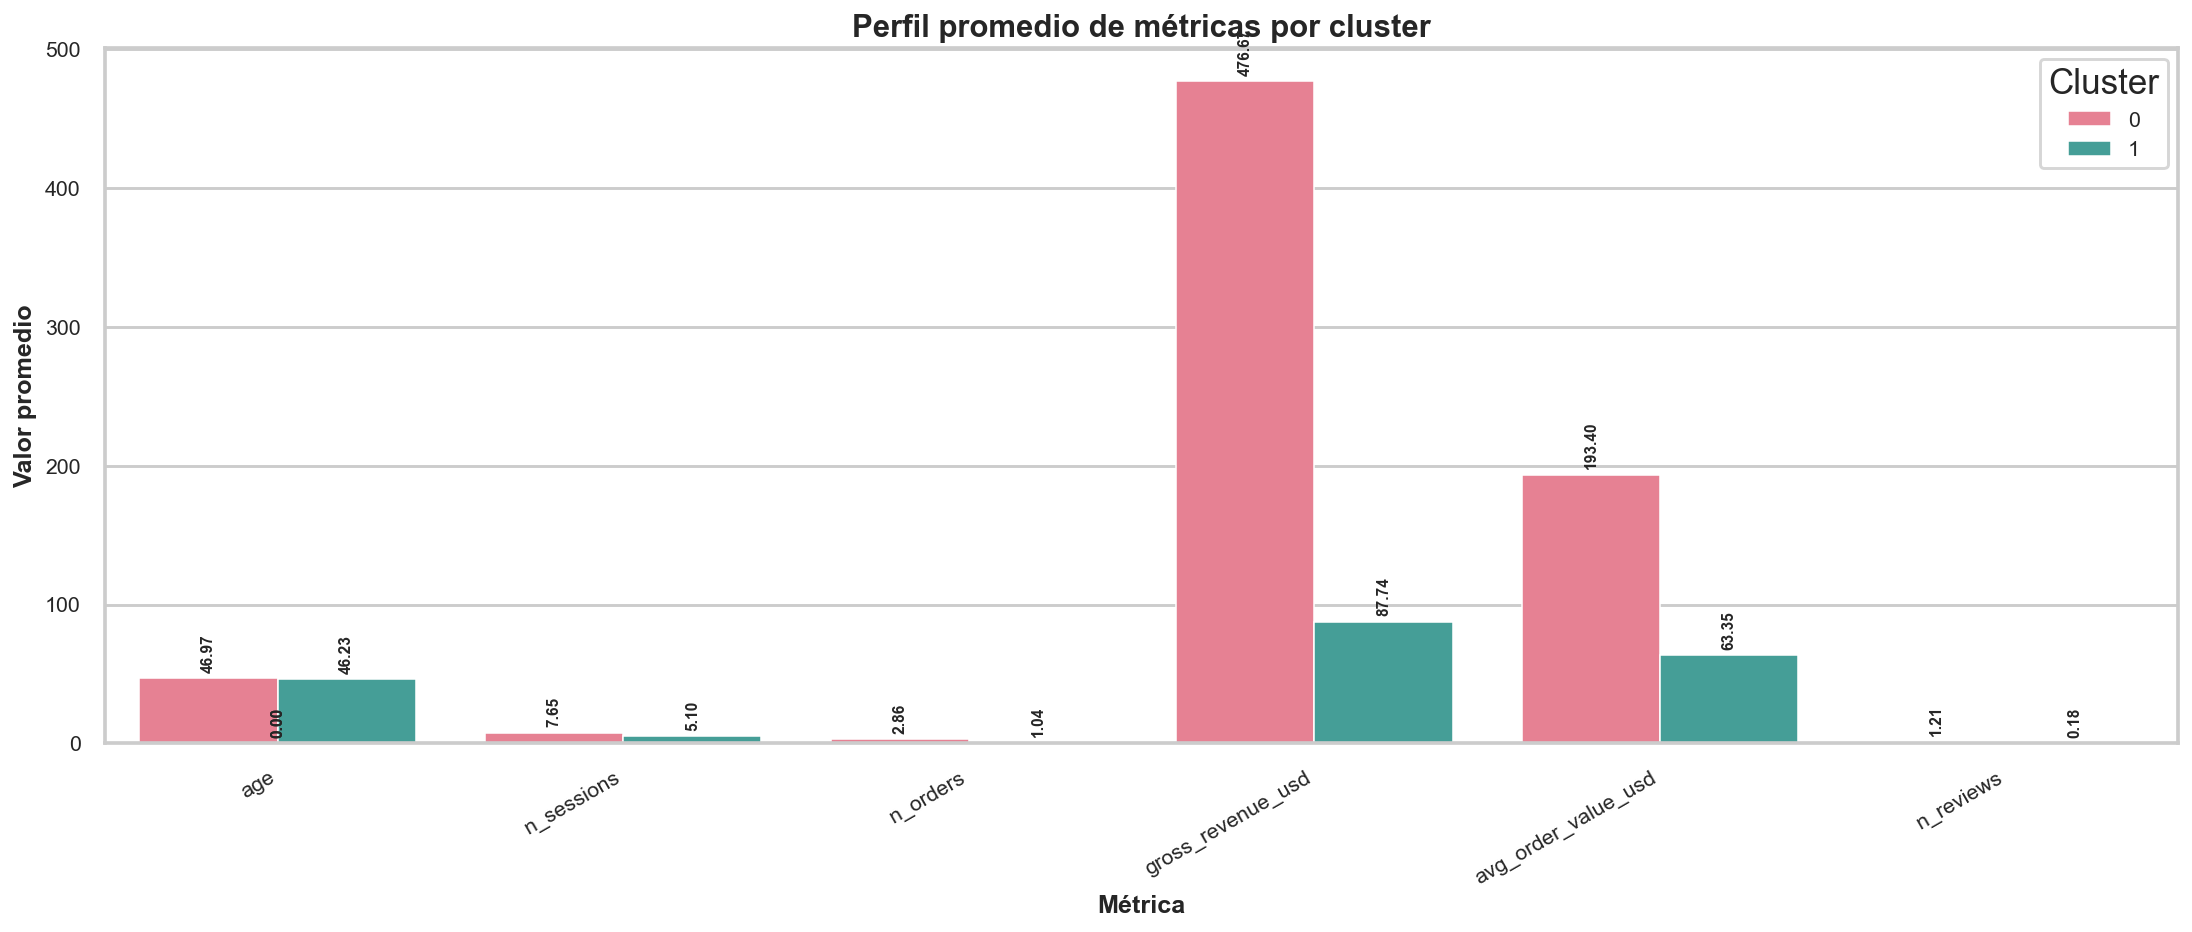

In [23]:
# Grafica el promedio de cada métrica por cluster y coloca el valor exacto sobre cada barra.
plt.figure(figsize=(16, 7))

ax = sns.barplot(
    data=cluster_profile_long,
    x="metric",
    y="mean_value",
    hue="cluster",
    palette=palette_clusters,
    edgecolor="white",
    linewidth=0.8
)

for patch in ax.patches:
    height = patch.get_height()
    if pd.notnull(height) and np.isfinite(height):
        ax.annotate(
            f"{height:.2f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            rotation=90,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title("Perfil promedio de métricas por cluster")
plt.xlabel("Métrica")
plt.ylabel("Valor promedio")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("perfil_promedio_clusters.png")
plt.show()

In [24]:
# Construye una tabla resumida con tamaño y perfil promedio de cada cluster.
cluster_summary = cluster_sizes.merge(cluster_profile, on="cluster", how="left")
cluster_summary

,cluster,customers_count,percentage,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,0,7041,35.20,46.97,7.65,2.86,476.67,193.40,1.21
1,1,12959,64.80,46.23,5.10,1.04,87.74,63.35,0.18


In [25]:
# Guarda el resumen final de clusters.
cluster_summary_output = PROCESSED_DIR / "customer_clusters_kmeans.csv"
cluster_summary.to_csv(cluster_summary_output, index=False)

print(f"Resumen final guardado en: {cluster_summary_output}")

Resumen final guardado en: G:\ProyectosPython\proyecto3\desarrollo3\data\processed\customer_clusters_kmeans.csv


## Visualización bidimensional de clusters

Se proyecta el comportamiento de los clientes en variables de negocio interpretables para observar la separación entre clusters.

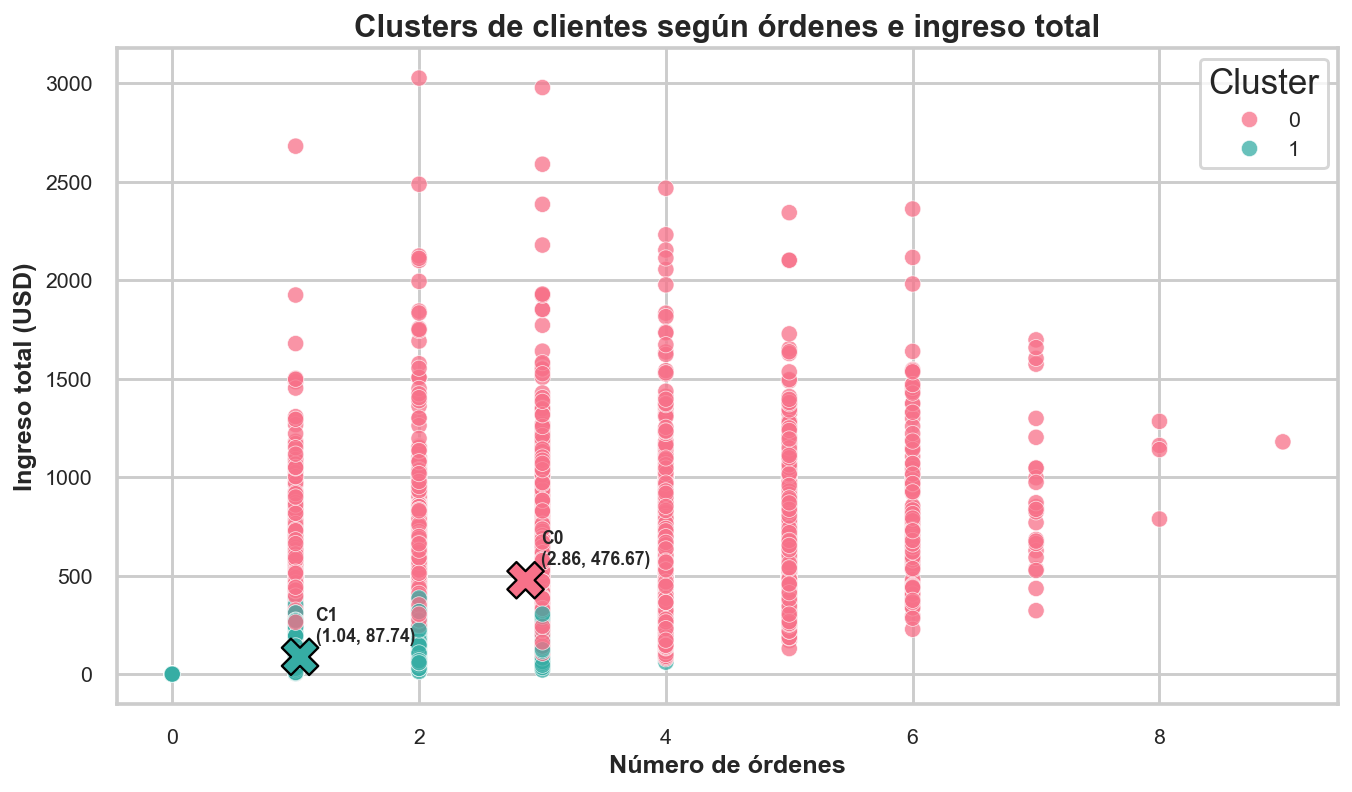

In [26]:
# Grafica los clusters usando ingreso total y número de órdenes como variables interpretables.
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=customer_features,
    x="n_orders",
    y="gross_revenue_usd",
    hue="cluster",
    palette=palette_clusters,
    alpha=0.75,
    s=70,
    edgecolor="white",
    linewidth=0.4
)

# Calcula centroides observables en el espacio original para añadirlos visualmente.
centroids_plot = (
    customer_features
    .groupby("cluster")[["n_orders", "gross_revenue_usd"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=centroids_plot,
    x="n_orders",
    y="gross_revenue_usd",
    hue="cluster",
    palette=palette_clusters,
    s=350,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    legend=False
)

for _, row in centroids_plot.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}\n({row['n_orders']:.2f}, {row['gross_revenue_usd']:.2f})",
        (row["n_orders"], row["gross_revenue_usd"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Clusters de clientes según órdenes e ingreso total")
plt.xlabel("Número de órdenes")
plt.ylabel("Ingreso total (USD)")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("scatter_clusters_ordenes_ingreso.png")
plt.show()

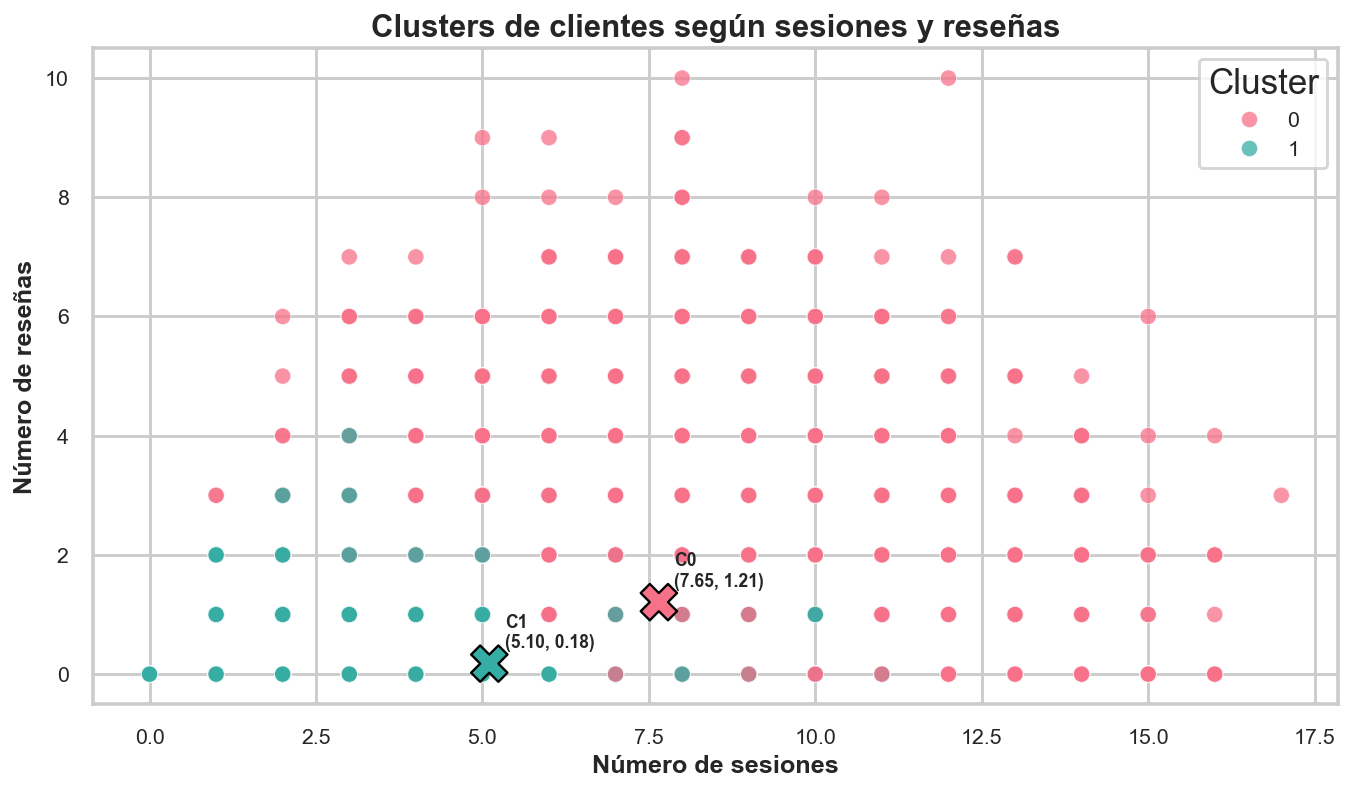

In [27]:
# Grafica los clusters usando sesiones y reseñas para otra vista del comportamiento del cliente.
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=customer_features,
    x="n_sessions",
    y="n_reviews",
    hue="cluster",
    palette=palette_clusters,
    alpha=0.75,
    s=70,
    edgecolor="white",
    linewidth=0.4
)

centroids_plot_2 = (
    customer_features
    .groupby("cluster")[["n_sessions", "n_reviews"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=centroids_plot_2,
    x="n_sessions",
    y="n_reviews",
    hue="cluster",
    palette=palette_clusters,
    s=350,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    legend=False
)

for _, row in centroids_plot_2.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}\n({row['n_sessions']:.2f}, {row['n_reviews']:.2f})",
        (row["n_sessions"], row["n_reviews"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Clusters de clientes según sesiones y reseñas")
plt.xlabel("Número de sesiones")
plt.ylabel("Número de reseñas")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("scatter_clusters_sesiones_resenas.png")
plt.show()

## Resultado de esta etapa

En este notebook se aplicó K-Means sobre la tabla `customer_features.csv`, se seleccionó un número de clusters con apoyo del método del codo y silhouette score, y se generaron tablas y gráficos para describir los segmentos de clientes identificados.

## 6. Visualización de clusters con PCA

Se aplica Análisis de Componentes Principales (PCA) sobre las variables estandarizadas usadas en K-Means para:
- reducir la dimensionalidad a 2 componentes principales,
- visualizar los clusters en un espacio 2D,
- analizar cuánta varianza explican los primeros componentes.

### Análisis de Componentes Principales (PCA)

A continuación se aplica PCA sobre las variables numéricas de clustering para reducir la dimensionalidad y visualizar la estructura de los segmentos en un plano bidimensional. Este análisis complementa la segmentación obtenida con K-Means al permitir identificar qué variables explican la mayor proporción de varianza y evaluar 
visualmente la separación entre clusters.

In [28]:
from sklearn.decomposition import PCA

In [29]:
# Aplica PCA sobre los datos escalados que ya usamos en K-Means.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape PCA:", X_pca.shape)

# Varianza explicada por cada componente.
explained_variance = pca.explained_variance_ratio_
explained_variance

Shape PCA: (20000, 2)


array([0.43223663, 0.1753235 ])

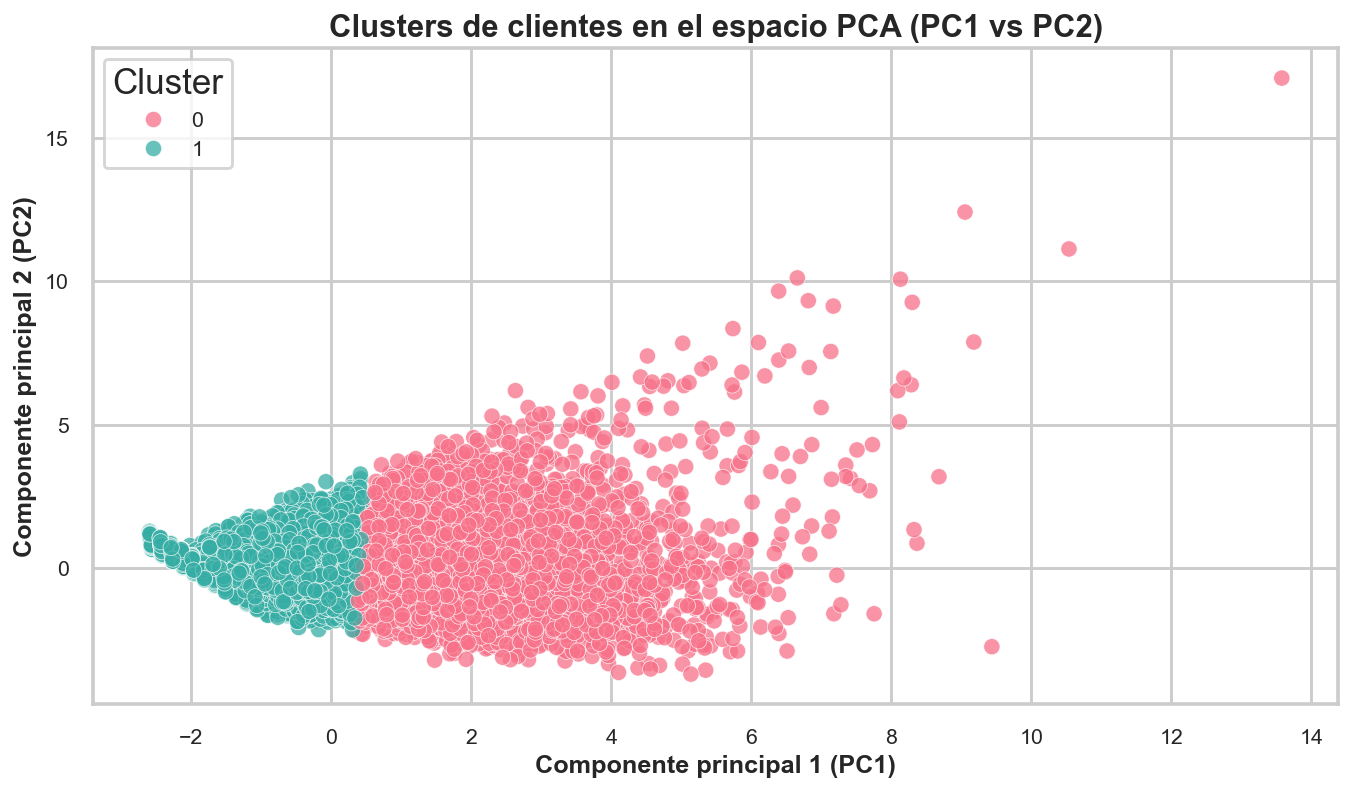

In [31]:
# Combina los dos primeros componentes principales con la etiqueta de cluster
pca_clusters_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
).assign(cluster=customer_features["cluster"])

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=pca_clusters_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=palette_clusters,   # usa la misma paleta que en otros gráficos
    alpha=0.75,
    s=70,
    edgecolor="white",
    linewidth=0.4
)

plt.title("Clusters de clientes en el espacio PCA (PC1 vs PC2)")
plt.xlabel("Componente principal 1 (PC1)")
plt.ylabel("Componente principal 2 (PC2)")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("pca_clusters_2d.png")
plt.show()

In [32]:
# Crea un DataFrame para la varianza explicada de cada componente.
pca_var_df = pd.DataFrame({
    "component": [1, 2],
    "explained_variance_ratio": explained_variance
})
pca_var_df["explained_variance_pct"] = (pca_var_df["explained_variance_ratio"] * 100).round(2)

pca_var_df

,component,explained_variance_ratio,explained_variance_pct
0,1,0.43,43.22
1,2,0.18,17.53


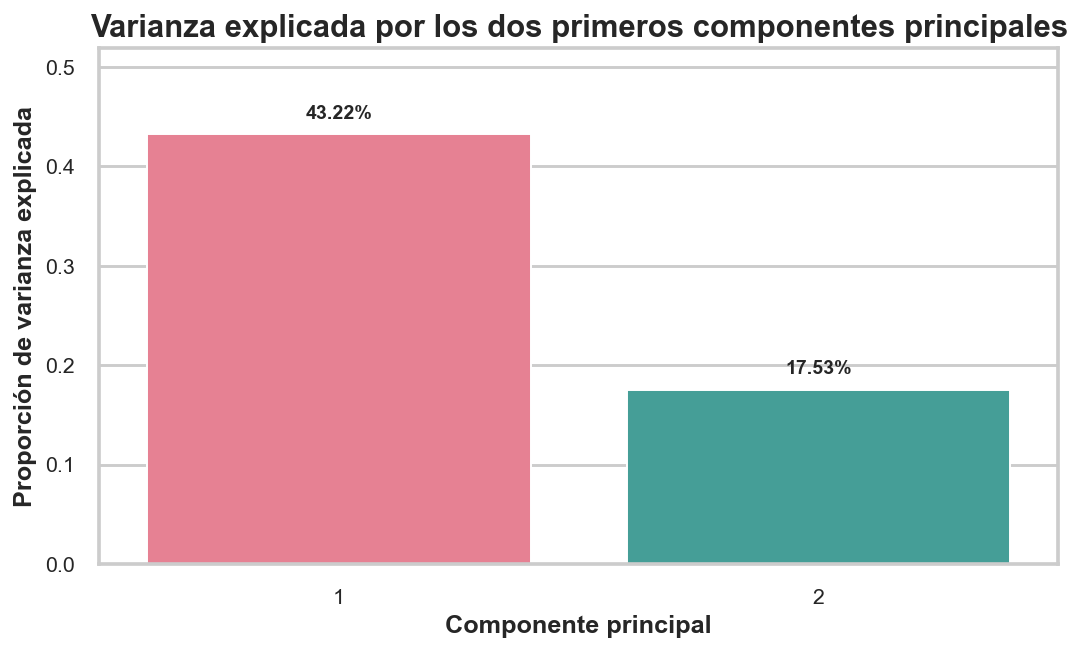

In [33]:
# Grafica la varianza explicada por cada componente principal e incluye los porcentajes en cada barra.
plt.figure(figsize=(8, 5))

# Convierte component a string para evitar comportamientos no deseados en seaborn.
pca_var_df["component"] = pca_var_df["component"].astype(str)

# Paleta exacta para el número de componentes graficados.
palette_pca = sns.color_palette("husl", n_colors=len(pca_var_df))

ax = sns.barplot(
    data=pca_var_df,
    x="component",
    y="explained_variance_ratio",
    hue="component",
    dodge=False,
    legend=False,
    palette=palette_pca,
    edgecolor="white",
    linewidth=1
)

for i, patch in enumerate(ax.patches):
    height = patch.get_height()
    pct = pca_var_df.loc[i, "explained_variance_pct"]
    ax.annotate(
        f"{pct:.2f}%",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points"
    )

plt.title("Varianza explicada por los dos primeros componentes principales")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.ylim(0, pca_var_df["explained_variance_ratio"].max() * 1.20)
plt.tight_layout()
save_plot("pca_varianza_explicada.png")
plt.show()

## 7. Interpretación de componentes principales

Se analizan los loadings de PCA para identificar qué variables originales contribuyen con mayor peso a los dos primeros componentes principales.

In [34]:
# Calcula los loadings de las variables originales sobre los dos primeros componentes principales.
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=["PC1", "PC2"]
).reset_index()

loadings_df = loadings_df.rename(columns={"index": "feature"})
loadings_df

,feature,PC1,PC2
0,age,0.01,-0.19
1,n_sessions,0.37,-0.52
2,n_orders,0.51,-0.31
3,gross_revenue_usd,0.56,0.31
4,avg_order_value_usd,0.42,0.65
5,n_reviews,0.33,-0.29


In [35]:
# Convierte la tabla de loadings a formato largo para facilitar la visualización.
loadings_long = loadings_df.melt(
    id_vars="feature",
    var_name="component",
    value_name="loading"
)

loadings_long["abs_loading"] = loadings_long["loading"].abs()
loadings_long.head()

,feature,component,loading,abs_loading
0,age,PC1,0.01,0.01
1,n_sessions,PC1,0.37,0.37
2,n_orders,PC1,0.51,0.51
3,gross_revenue_usd,PC1,0.56,0.56
4,avg_order_value_usd,PC1,0.42,0.42


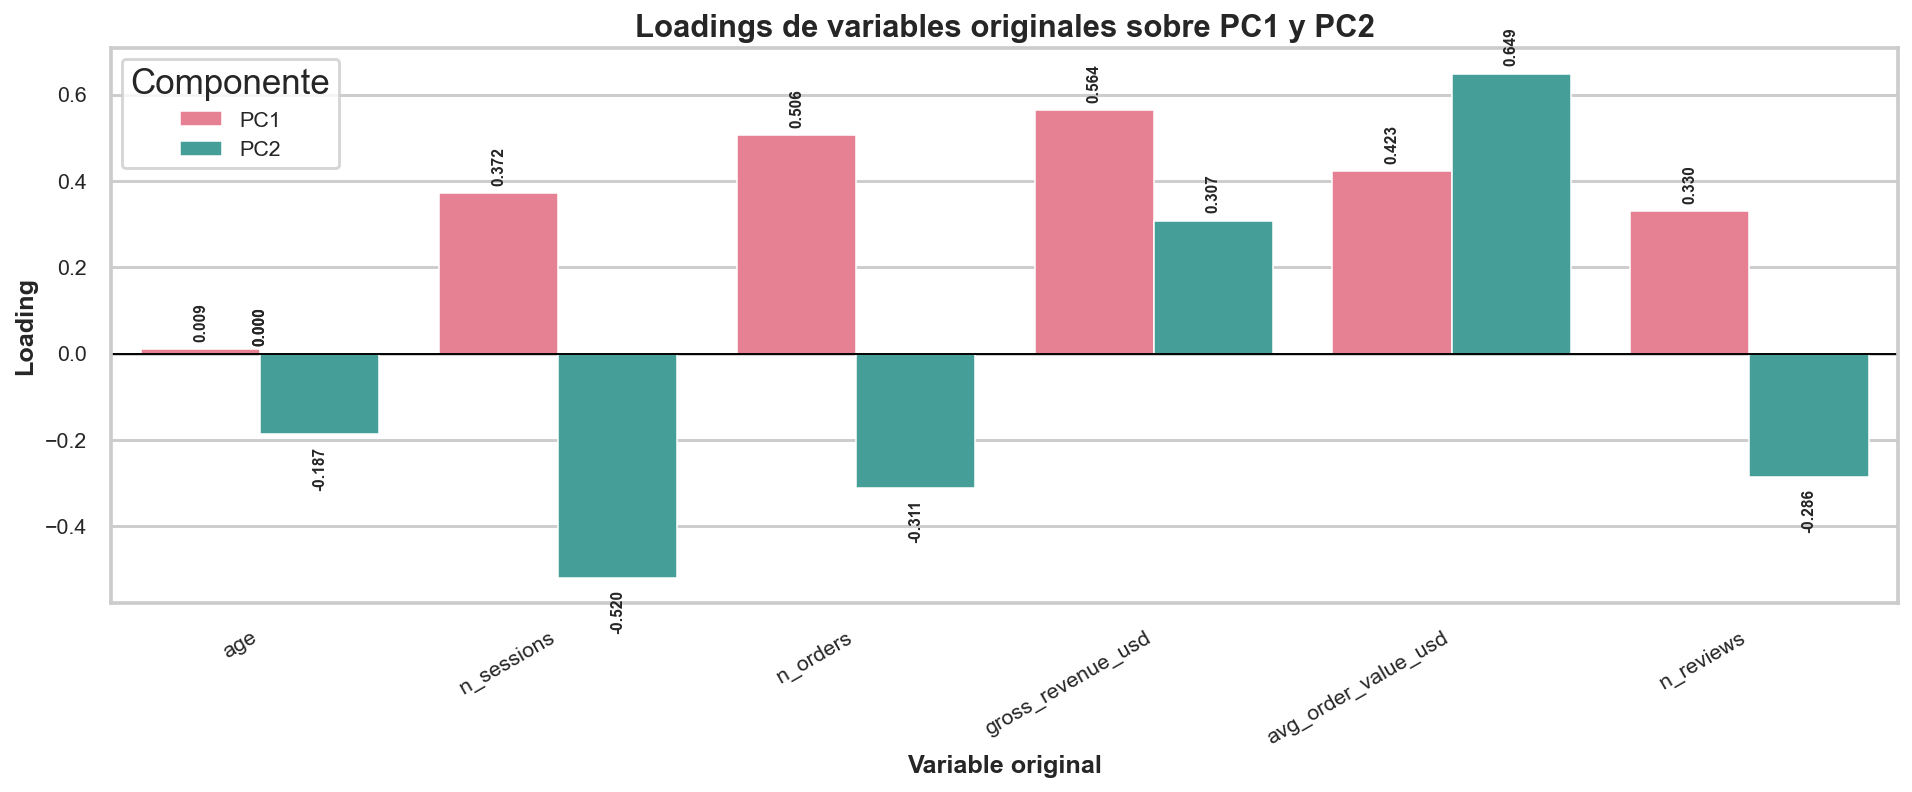

In [36]:
# Grafica los loadings por variable y componente, incluyendo el valor exacto sobre cada barra.
plt.figure(figsize=(14, 6))

loadings_long["component"] = loadings_long["component"].astype(str)
palette_loadings = sns.color_palette("husl", n_colors=loadings_long["component"].nunique())

ax = sns.barplot(
    data=loadings_long,
    x="feature",
    y="loading",
    hue="component",
    palette=palette_loadings,
    edgecolor="white",
    linewidth=0.8
)

for patch in ax.patches:
    height = patch.get_height()
    if pd.notnull(height) and np.isfinite(height):
        va = "bottom" if height >= 0 else "top"
        offset = 4 if height >= 0 else -6
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va=va,
            fontsize=8,
            fontweight="bold",
            rotation=90,
            xytext=(0, offset),
            textcoords="offset points"
        )

plt.axhline(0, color="black", linewidth=1)
plt.title("Loadings de variables originales sobre PC1 y PC2")
plt.xlabel("Variable original")
plt.ylabel("Loading")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Componente")
plt.tight_layout()
save_plot("pca_loadings_pc1_pc2.png")
plt.show()

In [37]:
# Muestra las variables más influyentes por componente usando el valor absoluto del loading.
top_loadings_pc1 = loadings_df[["feature", "PC1"]].copy()
top_loadings_pc1["abs_PC1"] = top_loadings_pc1["PC1"].abs()
top_loadings_pc1 = top_loadings_pc1.sort_values("abs_PC1", ascending=False)

top_loadings_pc2 = loadings_df[["feature", "PC2"]].copy()
top_loadings_pc2["abs_PC2"] = top_loadings_pc2["PC2"].abs()
top_loadings_pc2 = top_loadings_pc2.sort_values("abs_PC2", ascending=False)

print("Variables más influyentes en PC1")
display(top_loadings_pc1)

print("Variables más influyentes en PC2")
display(top_loadings_pc2)

Variables más influyentes en PC1


,feature,PC1,abs_PC1
3,gross_revenue_usd,0.56,0.56
2,n_orders,0.51,0.51
4,avg_order_value_usd,0.42,0.42
1,n_sessions,0.37,0.37
5,n_reviews,0.33,0.33
0,age,0.01,0.01


Variables más influyentes en PC2


,feature,PC2,abs_PC2
4,avg_order_value_usd,0.65,0.65
1,n_sessions,-0.52,0.52
2,n_orders,-0.31,0.31
3,gross_revenue_usd,0.31,0.31
5,n_reviews,-0.29,0.29
0,age,-0.19,0.19


## Interpretación final de los clusters K-Means

La evaluación del número de clusters mediante inercia y silhouette score indica que \(k=2\) ofrece el mejor compromiso entre compacidad interna y separación entre grupos. El silhouette score alcanza su valor máximo en \(k=2\) (≈ 0.30) y disminuye de forma progresiva para valores superiores, confirmando que una solución de dos segmentos es la más adecuada para este conjunto de datos.

El perfil medio de cada cluster revela diferencias claras en actividad e ingreso:

- **Cluster 0 — Clientes de alto valor** (≈ 35 % de la base): mayor número de sesiones (media 7.65), más órdenes por cliente (media 2.86), ingreso total notablemente superior (media USD 476.67) y ticket promedio elevado (media USD 193.40). También registra un número mayor de reseñas (media 1.21), lo que refleja un engagement más activo con la plataforma.

- **Cluster 1 — Clientes de menor valor** (≈ 65 % de la base): menor frecuencia de 
  sesiones (media 5.10), pocas órdenes (media 1.04), ingreso total reducido (media 
  USD 87.74) y ticket promedio bajo (media USD 63.35). Las reseñas son casi inexistentes 
  (media 0.18), indicando un nivel de interacción limitado.

Desde una perspectiva de negocio, esta segmentación permite diferenciar de forma 
directa clientes de alto y bajo valor, facilitando estrategias diferenciadas de 
priorización comercial, asignación de recursos de marketing y diseño de programas de 
retención o activación según el perfil de cada grupo.

## Interpretación final de PCA y visualización de segmentos

Los dos primeros componentes principales explican aproximadamente el 60 % de la 
varianza total (PC1: 43.22 %, PC2: 17.53 %), lo que justifica la representación 
bidimensional como una aproximación razonable de la estructura multivariada de los datos.

Los loadings de PC1 muestran que las variables de mayor contribución son 
`gross_revenue_usd` (0.56), `n_orders` (0.51) y `avg_order_value_usd` (0.42), por lo 
que este componente puede interpretarse como una **dimensión general de valor económico 
y volumen de compras**. PC2, en cambio, recibe su mayor aportación de 
`avg_order_value_usd` (0.65) con signo positivo y de `n_sessions` (−0.52) con signo 
negativo, lo que sugiere una **dimensión de contraste entre gasto por transacción y 
frecuencia de visitas**: clientes con ticket alto pero pocas sesiones se ubican en 
valores positivos de PC2, mientras que clientes muy frecuentes pero con gasto por orden 
más bajo tienden a valores negativos.

La proyección de los clusters en el plano PCA muestra que el cluster de alto valor se 
concentra en la zona de valores elevados de PC1, mientras que el cluster de menor valor 
se agrupa en la zona de valores bajos. Esta separación visual confirma que las 
diferencias capturadas por K-Means son coherentes con la estructura real de los datos 
y no un artefacto del algoritmo. En conjunto, el PCA refuerza la validez de la 
segmentación obtenida y ofrece una representación intuitiva de la distancia entre 
perfiles de cliente.

In [38]:
# ── Diagnóstico: verificar qué archivos de K-Means existen ───────────────────
import os
archivos_processed = list(PROCESSED_DIR.glob("*.csv"))
print("Archivos en PROCESSED_DIR:")
for f in archivos_processed:
    print(f"  {f.name}")

Archivos en PROCESSED_DIR:
  customer_clusters_kmeans.csv
  customer_features.csv
